# Logistic Regression Source-Zone Workflow

Dedicated notebook for interpretable logistic-regression source-zone experiments.

Main purpose:

- Reuse the raster/feature preparation from the random forest notebook.
- Build two binary targets:
  - `physics_dod`: non-channel cells where `C_MIN <= G < C_CHANNEL` and `dDEM < DZ_THRESHOLD`.
  - `dod_only`: non-channel cells where `dDEM < DZ_THRESHOLD`, without the lower `G` threshold.
- Fit logistic regression and export probability/class rasters.
- Print equations for `logit(P)` and `P(source)`.
- Optionally map logistic probability to a C-equivalent value using the empirical sampled `C` distribution.

Important: the logistic equation is statistical. The C-equivalent map is calibrated through the sampled `C` CDF, so it should be described as `C-equivalent` or `effective C`, not measured physical `C`.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import geometry_mask

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Find repo root whether notebook is run from repo root or notebooks/.
REPO = Path.cwd()
if not (REPO / "src").exists():
    REPO = REPO.parent
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from pci_source_zones.config import load_config, output_path
from pci_source_zones.inputs import read_raster

cfg = load_config(REPO / "config" / "montecito.yaml")

print("repo:", REPO)
print("site:", cfg.get("site"))

repo: /home/abdullah/pci-source-zones
site: montecito


## 2. Editable Inputs

In [11]:
# --------------------
# Paths
# --------------------
DATA = Path("/mnt/c/Users/amehedi/Downloads/thomas")
OUT = Path("/mnt/c/Users/amehedi/Downloads/source_area_workflow/logistic_regression")
OUT.mkdir(parents=True, exist_ok=True)

DEM_DIFF_PATH = DATA / "dem_diff_updated.tif"
C_SAMPLES_PATH = Path("/mnt/c/Users/amehedi/Downloads/source_area_workflow/c_samples.csv")

POLYGON_PATH = Path("/mnt/c/Users/amehedi/Downloads/dunne_lithology_polygons_unlabeled.gpkg")
POLYGON_ID_FIELD = "poly_id"
TRAIN_POLY_IDS = [3]
TEST_POLY_IDS = [4]
USE_POLYGON_SPLIT = False

# --------------------
# Target controls
# --------------------
C_MIN = 10          # try 5, 10, or 20
C_CHANNEL = 120     # channels omitted: G >= C_CHANNEL
DZ_THRESHOLD = -0.05
TARGET_NODATA = 255

# Choose one target:
# "physics_dod" = C/G range AND dDEM erosion, no channels
# "dod_only"    = dDEM erosion only, no channels
TARGET_NAME = "physics_dod"

# --------------------
# Logistic regression controls
# --------------------
RANDOM_SEED = 42
NEGATIVE_TO_POSITIVE_RATIO = 3
TEST_SIZE = 0.30
PROB_THRESHOLD = 0.50
SKIP_MISSING_FEATURES = True

# Use False if you want C-equivalent calibrated from the full sampled C distribution.
CALIBRATE_C_TO_SELECTED_RANGE = True

print("output folder:", OUT)

output folder: /mnt/c/Users/amehedi/Downloads/source_area_workflow/logistic_regression


## 3. Helpers

In [12]:
def first_existing(*paths):
    paths = [Path(p) for p in paths]
    for path in paths:
        if path.exists():
            return path
    return paths[0]


def check_same_grid(path, reference_profile):
    with rasterio.open(path) as src:
        same_shape = (src.height, src.width) == (
            reference_profile["height"],
            reference_profile["width"],
        )
        same_crs = src.crs == reference_profile["crs"]
        same_transform = src.transform.almost_equals(reference_profile["transform"])

    if not (same_shape and same_crs and same_transform):
        raise ValueError(
            f"Raster is not aligned with reference grid: {path}\n"
            f"same_shape={same_shape}, same_crs={same_crs}, same_transform={same_transform}"
        )


def write_uint8_raster(path, array, profile, nodata=255):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    meta = profile.copy()
    meta.update(
        driver="GTiff",
        count=1,
        dtype="uint8",
        nodata=nodata,
        compress="deflate",
    )
    if not meta.get("tiled", False):
        meta.pop("blockxsize", None)
        meta.pop("blockysize", None)
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(array.astype("uint8"), 1)
    return path


def write_float_raster(path, array, profile, nodata=-9999.0):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    data = np.asarray(array, dtype="float32")
    write_data = np.where(np.isfinite(data), data, nodata).astype("float32")
    meta = profile.copy()
    meta.update(
        driver="GTiff",
        count=1,
        dtype="float32",
        nodata=nodata,
        compress="deflate",
    )
    if not meta.get("tiled", False):
        meta.pop("blockxsize", None)
        meta.pop("blockysize", None)
    with rasterio.open(path, "w", **meta) as dst:
        dst.write(write_data, 1)
    return path


def print_class_counts(label, y):
    y = np.asarray(y)
    print(
        f"{label}: n={len(y)}, positive={int((y == 1).sum())}, "
        f"negative={int((y == 0).sum())}"
    )

## 4. Load Core Rasters

In [13]:
S, profile = read_raster(output_path(cfg, "slope", "slope.tif"))
a, _ = read_raster(output_path(cfg, "specific_catchment_area", "specific_catchment_area.tif"))
G, _ = read_raster(output_path(cfg, "topographic_driving_index", "topographic_driving_index.tif"))
dem_diff, _ = read_raster(DEM_DIFF_PATH)

cell_size = abs(float(profile["transform"].a))
DA = a * cell_size

core_valid = (
    np.isfinite(S) &
    np.isfinite(a) &
    np.isfinite(DA) &
    np.isfinite(G) &
    np.isfinite(dem_diff) &
    (S > 0) &
    (DA > 0) &
    (G > 0)
)

non_channel = core_valid & (G < C_CHANNEL)

print("grid shape:", G.shape)
print("valid non-channel cells:", int(non_channel.sum()))
print("G min/median/max in non-channel:", np.nanmin(G[non_channel]), np.nanmedian(G[non_channel]), np.nanmax(G[non_channel]))

grid shape: (835, 716)
valid non-channel cells: 484963
G min/median/max in non-channel: 1.2366555918845136e-18 10.217938423156738 119.99586486816406


## 5. Build Two Binary Targets

In [14]:
eroded = non_channel & (dem_diff < DZ_THRESHOLD)
physics_source = eroded & (G >= C_MIN) & (G < C_CHANNEL)
dod_only_source = eroded

targets = {}

for name, source_mask in {
    "physics_dod": physics_source,
    "dod_only": dod_only_source,
}.items():
    target = np.full(G.shape, TARGET_NODATA, dtype="uint8")
    target[non_channel] = 0
    target[source_mask] = 1
    targets[name] = target

    target_path = OUT / f"target_{name}_Cmin{C_MIN}_Cchannel{C_CHANNEL}_DZlt{str(DZ_THRESHOLD).replace('-', 'minus').replace('.', 'p')}.tif"
    write_uint8_raster(target_path, target, profile, nodata=TARGET_NODATA)

    print("saved:", target_path)
    print_class_counts(name, target[non_channel])

saved: /mnt/c/Users/amehedi/Downloads/source_area_workflow/logistic_regression/target_physics_dod_Cmin10_Cchannel120_DZltminus0p05.tif
physics_dod: n=484963, positive=103156, negative=381807
saved: /mnt/c/Users/amehedi/Downloads/source_area_workflow/logistic_regression/target_dod_only_Cmin10_Cchannel120_DZltminus0p05.tif
dod_only: n=484963, positive=170849, negative=314114


## 6. Select Features And Build X/y

In [15]:
# Keep G commented out by default because it is part of the physics_dod target definition.
# Run one model without G, then optionally add G to test whether it dominates.
SELECTED_FEATURES = [
    # "slope",
    # "specific_area",
    # "drainage_area",
    "G",
    "burn_severity",
    "soil_texture",
    "soil_thickness",
    "soil_density",
    "sand_total",
    "silt_total",
    "clay_total",
    "porosity",
    # "pH",
    "field_capacity",
    "saturated_water_content",
    "soil_transmissivity",
    "saturated_hydraulic_conductivity",
    "landcover",
    "et_diff",
    "ndvi_diff",
]

BASE_FEATURES = {
    "slope": S,
    "specific_area": a,
    "drainage_area": DA,
    "G": G,
}

FEATURE_FILES = {
    "burn_severity": DATA / "burn_severity_montecito_aoi_aligned.tif",
    "soil_texture": DATA / "soil__texture.tif",
    "soil_thickness": DATA / "soil__thickness.tif",
    "soil_density": DATA / "soil__density.tif",
    "sand_total": DATA / "sand__total.tif",
    "silt_total": DATA / "silt__total.tif",
    "clay_total": DATA / "clay__total.tif",
    "porosity": DATA / "porosity.tif",
    "pH": DATA / "pH.tif",
    "field_capacity": DATA / "field__capacity.tif",
    "saturated_water_content": DATA / "saturated__water_content.tif",
    "soil_transmissivity": DATA / "soil__transmissivity.tif",
    "saturated_hydraulic_conductivity": DATA / "soil__saturated_hydraulic_conductivity.tif",
    "landcover": DATA / "landcover.tif",
    "et_diff": first_existing(
        DATA / "gee_lai_ndvi_et" / "ET_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif",
        Path("/mnt/c/Users/amehedi/Downloads/gee_lai_ndvi_et/ET_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif"),
    ),
    "ndvi_diff": first_existing(
        DATA / "gee_lai_ndvi_et" / "NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif",
        Path("/mnt/c/Users/amehedi/Downloads/gee_lai_ndvi_et/NDVI_median_pre_2017-04-01_to_2017-08-30_post_2018-04-01_to_2018-08-30_diff_post_minus_pre_aligned.tif"),
    ),
}


def load_selected_features(selected_features):
    loaded = {}
    skipped = []

    for name in selected_features:
        if name in BASE_FEATURES:
            loaded[name] = BASE_FEATURES[name]
            continue

        path = Path(FEATURE_FILES[name])
        if not path.exists():
            message = f"missing feature {name}: {path}"
            if SKIP_MISSING_FEATURES:
                print("skipping", message)
                skipped.append((name, path))
                continue
            raise FileNotFoundError(message)

        check_same_grid(path, profile)
        arr, _ = read_raster(path)
        loaded[name] = arr

    return loaded, skipped


def build_xy(target_name):
    if target_name not in targets:
        raise ValueError(f"Unknown target {target_name!r}. Use one of {list(targets)}")

    features, skipped = load_selected_features(SELECTED_FEATURES)
    Y_raw = np.where(targets[target_name] == TARGET_NODATA, np.nan, targets[target_name].astype("float32"))
    Y = (Y_raw == 1).astype("uint8")

    valid = np.isfinite(Y_raw)
    for arr in features.values():
        valid &= np.isfinite(arr)

    X = pd.DataFrame({name: arr[valid] for name, arr in features.items()})
    y = Y[valid]

    return X, y, valid, features, skipped, Y_raw, Y

X, y, valid, features, skipped_features, Y_raw, Y = build_xy(TARGET_NAME)

print("target:", TARGET_NAME)
print("features:", list(X.columns))
print("skipped features:", [name for name, _ in skipped_features])
print("X shape:", X.shape)
print_class_counts("training table", y)
X.head()

target: physics_dod
features: ['G', 'burn_severity', 'soil_texture', 'soil_thickness', 'soil_density', 'sand_total', 'silt_total', 'clay_total', 'porosity', 'field_capacity', 'saturated_water_content', 'soil_transmissivity', 'saturated_hydraulic_conductivity', 'landcover', 'et_diff', 'ndvi_diff']
skipped features: []
X shape: (473736, 16)
training table: n=473736, positive=101787, negative=371949


,G,burn_severity,soil_texture,soil_thickness,soil_density,sand_total,silt_total,clay_total,porosity,field_capacity,saturated_water_content,soil_transmissivity,saturated_hydraulic_conductivity,landcover,et_diff,ndvi_diff
0,3.592833e-15,0.0,3.0,37.0,2902.654785,57.0,25.0,17.0,0.435,0.249379,0.377354,1.471184,3.976172,43.0,2.124098,-0.022619
1,7.185666e-15,0.0,3.0,37.0,2902.654785,57.0,25.0,17.0,0.435,0.249379,0.377354,1.467672,3.966680,43.0,2.220644,-0.022645
2,1.197611e-14,0.0,3.0,38.0,2902.654785,57.0,25.0,18.0,0.435,0.249379,0.377627,1.420066,3.737016,43.0,2.317190,-0.022671
3,1.796417e-14,0.0,3.0,38.0,2920.354004,57.0,25.0,18.0,0.435,0.249379,0.374805,1.420066,3.737016,43.0,2.195271,-0.028909
4,2.514983e-14,0.0,3.0,37.0,2920.354004,57.0,25.0,18.0,0.435,0.249379,0.374805,1.371123,3.705739,43.0,1.992476,-0.036365


Note: categorical rasters such as burn severity and landcover are treated as numeric codes in this simple logistic model. That is useful for a first pass, but coefficient interpretation is cleaner for continuous predictors. If needed, those categorical predictors can be one-hot encoded later.

## 7. Train/Test Split

In [16]:
if USE_POLYGON_SPLIT:
    polys = gpd.read_file(POLYGON_PATH)
    if polys.crs != profile["crs"]:
        polys = polys.to_crs(profile["crs"])

    train_geom = polys.loc[polys[POLYGON_ID_FIELD].isin(TRAIN_POLY_IDS), "geometry"]
    test_geom = polys.loc[polys[POLYGON_ID_FIELD].isin(TEST_POLY_IDS), "geometry"]

    train_mask = geometry_mask(
        train_geom,
        out_shape=G.shape,
        transform=profile["transform"],
        invert=True,
    )
    test_mask = geometry_mask(
        test_geom,
        out_shape=G.shape,
        transform=profile["transform"],
        invert=True,
    )

    train_valid = valid & train_mask
    test_valid = valid & test_mask

    X_train = pd.DataFrame({name: arr[train_valid] for name, arr in features.items()})
    y_train = Y[train_valid]
    X_test = pd.DataFrame({name: arr[test_valid] for name, arr in features.items()})
    y_test = Y[test_valid]

else:
    pos = np.where(y == 1)[0]
    neg = np.where(y == 0)[0]

    rng = np.random.default_rng(RANDOM_SEED)
    neg_sample = rng.choice(
        neg,
        size=min(len(neg), len(pos) * NEGATIVE_TO_POSITIVE_RATIO),
        replace=False,
    )
    idx = np.concatenate([pos, neg_sample])
    rng.shuffle(idx)

    X_train, X_test, y_train, y_test = train_test_split(
        X.iloc[idx],
        y[idx],
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=y[idx],
    )

print_class_counts("train", y_train)
print_class_counts("test", y_test)

train: n=285003, positive=71251, negative=213752
test: n=122145, positive=30536, negative=91609


## 8. Fit Logistic Regression

target: physics_dod
[[65565 26044]
 [ 6725 23811]]
              precision    recall  f1-score   support

           0       0.91      0.72      0.80     91609
           1       0.48      0.78      0.59     30536

    accuracy                           0.73    122145
   macro avg       0.69      0.75      0.70    122145
weighted avg       0.80      0.73      0.75    122145



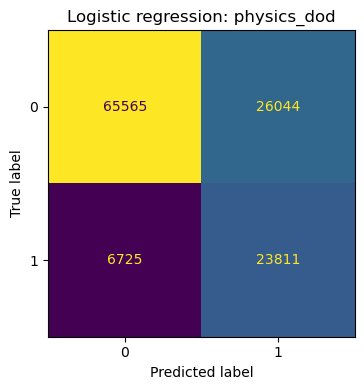

In [17]:
logit = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_SEED,
    )),
])

logit.fit(X_train, y_train)

test_pred = logit.predict(X_test)
test_prob = logit.predict_proba(X_test)[:, 1]

print("target:", TARGET_NAME)
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred, zero_division=0))

fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, ax=ax, colorbar=False)
ax.set_title(f"Logistic regression: {TARGET_NAME}")
plt.tight_layout()
plt.show()

## 9. Coefficients And Equations

In [18]:
model = logit.named_steps["model"]
scaler = logit.named_steps["scaler"]

features_used = list(X_train.columns)
coef_std = model.coef_[0]
intercept_std = float(model.intercept_[0])

# Convert standardized-feature equation to original input units.
coef_raw = coef_std / scaler.scale_
intercept_raw = intercept_std - np.sum(coef_std * scaler.mean_ / scaler.scale_)

coef_table = pd.DataFrame({
    "feature": features_used,
    "coef_standardized": coef_std,
    "coef_raw_units": coef_raw,
    "mean_used_for_standardizing": scaler.mean_,
    "scale_used_for_standardizing": scaler.scale_,
}).sort_values("coef_standardized", ascending=False)

coef_csv = OUT / f"logistic_coefficients_{TARGET_NAME}.csv"
coef_table.to_csv(coef_csv, index=False)
print("saved coefficients:", coef_csv)


def equation_string(intercept, coefs, names, z_prefix=""):
    terms = [f"{intercept:.4g}"]
    for coef, name in zip(coefs, names):
        sign = "+" if coef >= 0 else "-"
        terms.append(f" {sign} {abs(coef):.4g}*{z_prefix}{name}")
    return "".join(terms)

eta_std = equation_string(intercept_std, coef_std, features_used, z_prefix="z_")
eta_raw = equation_string(intercept_raw, coef_raw, features_used, z_prefix="")

print("Standardized-feature equation:")
print("logit(P_source) =", eta_std)
print("P_source = 1 / (1 + exp(-logit(P_source)))")
print()
print("Original-unit equation:")
print("logit(P_source) =", eta_raw)

coef_table

saved coefficients: /mnt/c/Users/amehedi/Downloads/source_area_workflow/logistic_regression/logistic_coefficients_physics_dod.csv
Standardized-feature equation:
logit(P_source) = -0.4321 + 0.8988*z_G - 0.04058*z_burn_severity - 0.02942*z_soil_texture - 0.3616*z_soil_thickness - 0.005959*z_soil_density - 0.14*z_sand_total + 0.1741*z_silt_total + 0.1203*z_clay_total - 0.07089*z_porosity - 0.06231*z_field_capacity - 0.05945*z_saturated_water_content - 0.6204*z_soil_transmissivity + 0.2392*z_saturated_hydraulic_conductivity + 0.07061*z_landcover - 0.03056*z_et_diff - 0.4412*z_ndvi_diff
P_source = 1 / (1 + exp(-logit(P_source)))

Original-unit equation:
logit(P_source) = 7.242 + 0.04042*G - 0.02989*burn_severity - 0.04879*soil_texture - 0.006474*soil_thickness - 0.00012*soil_density - 0.02756*sand_total + 0.05011*silt_total + 0.05934*clay_total - 9.85*porosity - 2.204*field_capacity - 11.46*saturated_water_content - 0.2113*soil_transmissivity + 0.2919*saturated_hydraulic_conductivity + 0.00

,feature,coef_standardized,coef_raw_units,mean_used_for_standardizing,scale_used_for_standardizing
0,G,0.898768,0.040420,19.105238,22.235724
12,saturated_hydraulic_conductivity,0.239169,0.291874,3.801141,0.819425
6,silt_total,0.174064,0.050114,25.288155,3.473368
7,clay_total,0.120270,0.059339,18.469160,2.026827
13,landcover,0.070611,0.004616,40.602766,15.296950
4,soil_density,-0.005959,-0.000120,2888.487037,49.648689
2,soil_texture,-0.029417,-0.048785,3.297078,0.602992
14,et_diff,-0.030559,-0.000751,-22.389714,40.676483
1,burn_severity,-0.040581,-0.029893,1.069659,1.357566
10,saturated_water_content,-0.059447,-11.455528,0.383190,0.005189


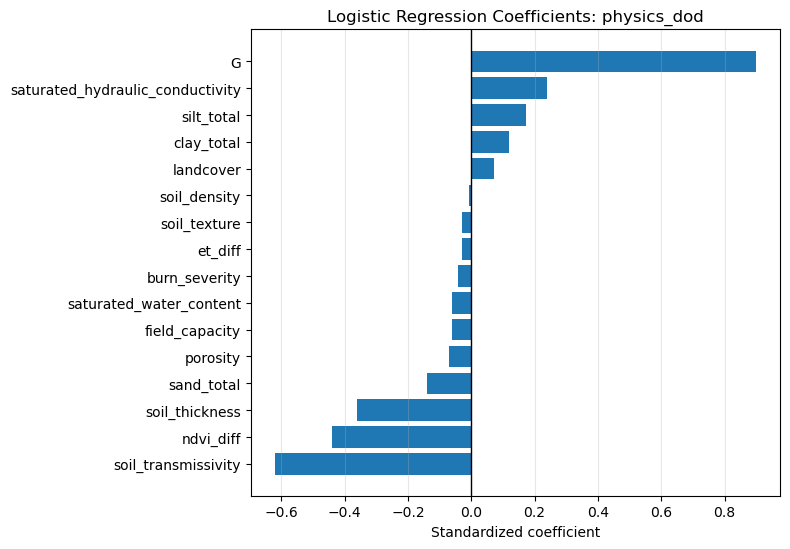

saved coefficient plot: /mnt/c/Users/amehedi/Downloads/source_area_workflow/logistic_regression/logistic_coefficients_physics_dod.png


In [19]:
plot_df = coef_table.sort_values("coef_standardized")

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(plot_df))))
ax.barh(plot_df["feature"], plot_df["coef_standardized"])
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Standardized coefficient")
ax.set_title(f"Logistic Regression Coefficients: {TARGET_NAME}")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

coef_png = OUT / f"logistic_coefficients_{TARGET_NAME}.png"
fig.savefig(coef_png, dpi=200)
plt.show()
print("saved coefficient plot:", coef_png)

## 10. Export Probability, Class, And Score Rasters

In [ ]:
X_full = pd.DataFrame({name: arr[valid] for name, arr in features.items()})

prob_values = logit.predict_proba(X_full)[:, 1].astype("float32")
score_values = logit.decision_function(X_full).astype("float32")
resistance_index_values = (-score_values).astype("float32")

prob_map = np.full(G.shape, np.nan, dtype="float32")
score_map = np.full(G.shape, np.nan, dtype="float32")
resistance_index_map = np.full(G.shape, np.nan, dtype="float32")
class_map = np.full(G.shape, TARGET_NODATA, dtype="uint8")

prob_map[valid] = prob_values
score_map[valid] = score_values
resistance_index_map[valid] = resistance_index_values
class_map[valid] = (prob_values >= PROB_THRESHOLD).astype("uint8")

prob_path = OUT / f"logistic_probability_{TARGET_NAME}.tif"
score_path = OUT / f"logistic_logit_score_{TARGET_NAME}.tif"
resistance_path = OUT / f"logistic_effective_resistance_index_{TARGET_NAME}.tif"
class_path = OUT / f"logistic_class_{TARGET_NAME}_p{str(PROB_THRESHOLD).replace('.', 'p')}.tif"

write_float_raster(prob_path, prob_map, profile)
write_float_raster(score_path, score_map, profile)
write_float_raster(resistance_path, resistance_index_map, profile)
write_uint8_raster(class_path, class_map, profile, nodata=TARGET_NODATA)

print("saved probability:", prob_path)
print("saved logit score:", score_path)
print("saved effective resistance index:", resistance_path)
print("saved class:", class_path)
print("predicted source cells:", int((class_map == 1).sum()))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

im0 = axes[0].imshow(prob_map, cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Logistic probability")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

axes[1].imshow(np.where(class_map == TARGET_NODATA, np.nan, class_map), cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Class, p >= {PROB_THRESHOLD}")

axes[2].imshow(np.where(np.isfinite(Y_raw), Y, np.nan), cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"Target: {TARGET_NAME}")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plot_path = OUT / f"logistic_maps_{TARGET_NAME}.png"
fig.savefig(plot_path, dpi=200)
plt.show()
print("saved map plot:", plot_path)

## 11. Optional C-Equivalent Calibration

This maps logistic probability to the empirical sampled `C` distribution:

`C_equivalent = F_C^{-1}(P_logistic)`

This is not measured physical `C`. It is a C-equivalent threshold value inferred from the sampled C distribution and the logistic probability.

In [ ]:
if not C_SAMPLES_PATH.exists():
    print("missing C samples:", C_SAMPLES_PATH)
else:
    c_table = pd.read_csv(C_SAMPLES_PATH)
    C_values = c_table["C"].dropna().to_numpy()
    C_values = C_values[np.isfinite(C_values) & (C_values > 0)]

    if CALIBRATE_C_TO_SELECTED_RANGE:
        C_values = C_values[(C_values >= C_MIN) & (C_values < C_CHANNEL)]

    if len(C_values) == 0:
        raise ValueError("No C values available for calibration.")

    q = np.clip(prob_values, 1e-6, 1 - 1e-6)
    C_equiv_values = np.quantile(C_values, q).astype("float32")

    C_equiv_map = np.full(G.shape, np.nan, dtype="float32")
    C_equiv_map[valid] = C_equiv_values

    C_equiv_path = OUT / f"logistic_C_equivalent_{TARGET_NAME}.tif"
    write_float_raster(C_equiv_path, C_equiv_map, profile)

    print("saved C-equivalent raster:", C_equiv_path)
    print("C calibration samples:", len(C_values))
    print("C min/median/max:", np.nanmin(C_values), np.nanmedian(C_values), np.nanmax(C_values))
    print("C-equivalent min/median/max:", np.nanmin(C_equiv_values), np.nanmedian(C_equiv_values), np.nanmax(C_equiv_values))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].hist(prob_values, bins=40, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Logistic probability")
    axes[0].set_ylabel("Cell count")
    axes[0].set_title("Probability distribution")

    axes[1].hist(C_equiv_values, bins=40, color="darkorange", edgecolor="white")
    axes[1].set_xlabel("C-equivalent")
    axes[1].set_ylabel("Cell count")
    axes[1].set_title("C-equivalent distribution")

    plt.tight_layout()
    hist_path = OUT / f"logistic_probability_and_C_equivalent_hist_{TARGET_NAME}.png"
    fig.savefig(hist_path, dpi=200)
    plt.show()
    print("saved histogram:", hist_path)

## 12. Run The Other Target

In [ ]:
# To train the other target, change TARGET_NAME above and rerun sections 6 onward.
# Options:
# TARGET_NAME = "physics_dod"
# TARGET_NAME = "dod_only"

print("current target:", TARGET_NAME)
print("available targets:", list(targets))

eta = b0 + sum(bi * xi)
eta = 4.25552 + (1.81138 * slope) + (-1.37106e-07 * drainage_area) + (-0.0161743 * burn_severity) + (-0.00585165 * soil_texture) + (-0.00566494 * soil_thickness) + (0.000142533 * soil_density) + (-0.021909 * sand_total) + (0.0582142 * silt_total) + (0.0616051 * clay_total) + (-9.52894 * porosity) + (-1.70865 * field_capacity) + (-8.31227 * saturated_water_content) + (-0.199879 * soil_transmissivity) + (0.337531 * saturated_hydraulic_conductivity) + (-3.10445e-05 * landcover) + (0.000499259 * et_diff) + (-3.60331 * ndvi_diff)

P_source = 1 / (1 + exp(-eta))
C_equiv = F_C^-1(P_source)

Full:
C_equiv = F_C^-1(1 / (1 + exp(-( 4.25552 + (1.81138 * slope) + (-1.37106e-07 * drainage_area) + (-0.0161743 * burn_severity) + (-0.00585165 * soil_texture) + (-0.00566494 * soil_thickness) + (0.000142533 * soil_density) + (-0.021909 * sand_total) + (0.0582142 * silt_total) + (0.0616051 * clay_total) + (-9.52894 * porosity) + (-1.70865 * field_capacity) + (-8.31227 * saturated_

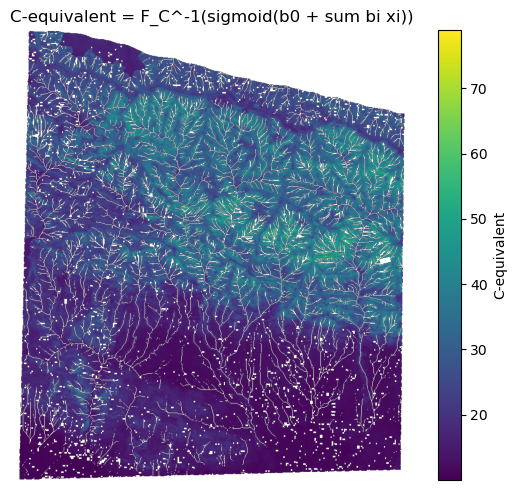

In [12]:
# --------------------
# C_equiv = F_C^-1(sigmoid(b0 + sum(bi * xi)))
# using ORIGINAL feature units
# --------------------

c_path = "/mnt/c/Users/amehedi/Downloads/source_area_workflow/c_samples.csv"

# 1. Get original-unit logistic coefficients
model = logit.named_steps["model"]
scaler = logit.named_steps["scaler"]

feature_names = list(X_train.columns)

coef_std = model.coef_[0]
intercept_std = model.intercept_[0]

coef_raw = coef_std / scaler.scale_
intercept_raw = intercept_std - np.sum(coef_std * scaler.mean_ / scaler.scale_)

# 2. Print C-equivalent equation
terms = [
    f"({coef_raw[i]:.6g} * {feature_names[i]})"
    for i in range(len(feature_names))
]

linear_eq = f"{intercept_raw:.6g} + " + " + ".join(terms)

print("eta = b0 + sum(bi * xi)")
print("eta =", linear_eq)
print()
print("P_source = 1 / (1 + exp(-eta))")
print("C_equiv = F_C^-1(P_source)")
print()
print("Full:")
print("C_equiv = F_C^-1(1 / (1 + exp(-(", linear_eq, "))))")

# 3. Compute eta directly from original X values
X_full = pd.DataFrame({
    name: arr[valid]
    for name, arr in features.items()
})

eta = intercept_raw + X_full[feature_names].values @ coef_raw
P_source = 1 / (1 + np.exp(-eta))

# 4. Empirical inverse CDF
c_table = pd.read_csv(c_path)
C_values = c_table["C"].dropna().values
C_values = C_values[np.isfinite(C_values) & (C_values > 0)]

# optional: use same C range as target
C_values = C_values[(C_values >= C_MIN) & (C_values < C_CHANNEL)]

P_clip = np.clip(P_source, 1e-6, 1 - 1e-6)
C_equiv_values = np.quantile(C_values, P_clip).astype("float32")

# 5. Rasterize and export
C_equiv_map = np.full(G.shape, np.nan, dtype="float32")
C_equiv_map[valid] = C_equiv_values

C_equiv_path = OUT / f"logistic_C_equivalent_equation_{TARGET_NAME}.tif"
write_float_raster(C_equiv_path, C_equiv_map, profile)

print("saved:", C_equiv_path)
print("C_equiv min:", np.nanmin(C_equiv_values))
print("C_equiv median:", np.nanmedian(C_equiv_values))
print("C_equiv max:", np.nanmax(C_equiv_values))

# 6. Plot
plt.figure(figsize=(7, 5))
plt.imshow(C_equiv_map, cmap="viridis")
plt.colorbar(label="C-equivalent")
plt.title(f"C-equivalent = F_C^-1(sigmoid(b0 + sum bi xi))")
plt.axis("off")
plt.tight_layout()
plt.show()

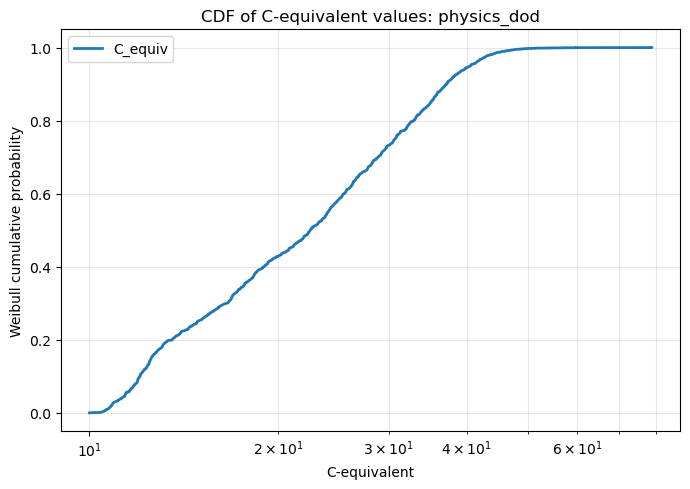

cells: 473736
min: 10.014163
median: 22.509604
max: 78.8624


In [13]:
# CDF of C-equivalent values

values = C_equiv_values[np.isfinite(C_equiv_values)]

x = np.sort(values)
y = np.arange(1, len(x) + 1) / (len(x) + 1)

plt.figure(figsize=(7, 5))
plt.step(x, y, where="post", linewidth=2, label="C_equiv")

plt.xscale("log")
plt.xlabel("C-equivalent")
plt.ylabel("Weibull cumulative probability")
plt.title(f"CDF of C-equivalent values: {TARGET_NAME}")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("cells:", len(values))
print("min:", np.nanmin(values))
print("median:", np.nanmedian(values))
print("max:", np.nanmax(values))